# Simple and Multiple Linear Regression in Algorithmic Trading: A Practical Guide for Quants

#### Se importan las librerías necesarias para la descarga de datos históricos 

In [ ]:
import yfinance as yf                    
import pandas as pd         
!pip install statsmodels -q             
import statsmodels.api as sm # For OLS regression modeling            
import matplotlib.pyplot as plt  

#### Descarga de los precios de cierre diarios para las acciones de Apple y S&P500 en el periodo de 1 año

In [ ]:
data_stocks = yf.download(['AAPL','SPY'], start='2024-11-25', end='2025-11-25')['Close']

/tmp/ipykernel_12730/309419507.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_stocks = yf.download(['AAPL','SPY'], start='2024-11-25', end='2025-11-25')['Close']
[*********************100%***********************]  2 of 2 completed


#### Se descartan las filas con información faltante, missing values.

In [10]:
data_stocks = data_stocks.dropna()
data_stocks

Ticker,AAPL,SPY
Date,,
2024-11-25,231.821518,590.352783
2024-11-26,234.001663,593.435364
2024-11-27,233.872269,591.637146
2024-11-29,236.261459,595.312500
2024-12-02,238.511261,596.379578
...,...,...
2025-11-18,267.440002,660.080017
2025-11-19,268.559998,662.630005
2025-11-20,266.250000,652.530029


#### Cálculo de los retornos diarios de las acciones de Apple y S&P500

In [12]:
returns = data_stocks.pct_change().dropna()
returns

Ticker,AAPL,SPY
Date,,
2024-11-26,0.009404,0.005222
2024-11-27,-0.000553,-0.003030
2024-11-29,0.010216,0.006212
2024-12-02,0.009523,0.001792
2024-12-03,0.012772,0.000464
...,...,...
2025-11-18,-0.000075,-0.008398
2025-11-19,0.004188,0.003863
2025-11-20,-0.008601,-0.015242


#### Se definen los retornos de Apple como la variable dependiente (Y) 

In [14]:
Y = returns['AAPL']

#### Se definen los retornos del S&P500 como como la variable independiente (X)

In [15]:
X = returns['SPY']

#### Se agrega una constante a X para incluir el intercepto (β₀) en la regresión

In [16]:
X = sm.add_constant(X)

#### Se ajusta el modelo de regresón de minimos cuadrados ordinarios (OLS)

In [18]:
model = sm.OLS(Y,X).fit()

#### Se muestra el resumen de los resultados de la regresión

In [20]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.569
Method:                 Least Squares   F-statistic:                     328.7
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           2.77e-47
Time:                        03:40:20   Log-Likelihood:                 718.95
No. Observations:                 249   AIC:                            -1434.
Df Residuals:                     247   BIC:                            -1427.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.001      0.218      0.8

#### Se grafica la linea de regresión

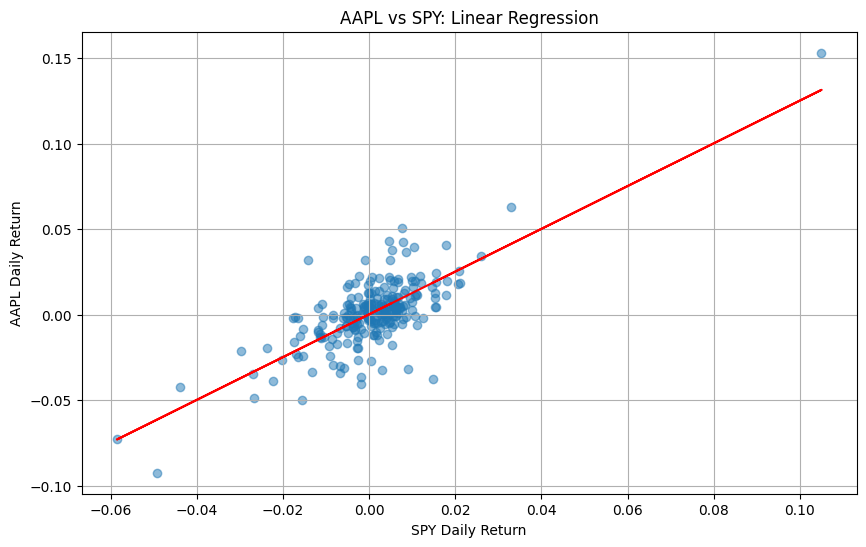

In [26]:
plt.figure(figsize=(10,6))
plt.scatter(returns['SPY'], returns['AAPL'], alpha=0.5)
plt.plot(returns['SPY'], model.predict(X), color='red')

plt.title("AAPL vs SPY: Linear Regression")
plt.xlabel("SPY Daily Return")
plt.ylabel("AAPL Daily Return")

plt.grid(True)
plt.show()